In [1]:
# Record both rgbd camera, robot state, action
import numpy as np
from copy import deepcopy
from dataclasses import dataclass
import time
import os
from enum import Enum, auto
from typing import Callable


@dataclass
class RobotState:
    time_stamp:float=0.0
    q:np.ndarray=None
    dq:np.ndarray=None
    eef_pose:np.ndarray=None
    gripper_width:float = 0.0
    wrist_camera_rgb_image: np.ndarray=None
    wrist_camera_depth_image: np.ndarray=None
    external_camera_rgb_image: np.ndarray=None
    external_camera_depth_image: np.ndarray=None


@dataclass
class RobotAction:
    time_stamp:float=0.0
    eef_action:np.ndarray=None # 6 for x,y,z,rx,ry,rz
    gripper_action:np.ndarray=None # 4 for belt gripper, 1 for parallel gripper, 1 for panda gripper



In [22]:
import numpy as np
import pickle

path = "data/recorded_trajectory/ood_trajectories/green_cup_to_blue_/recorded_traj_30.npy"
with open(path, "rb") as f:
    data = pickle.load(f)

In [20]:
data[-50][0].external_camera_rgb_image.shape

(224, 224, 3)

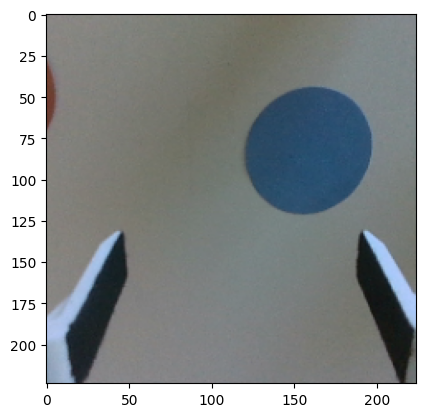

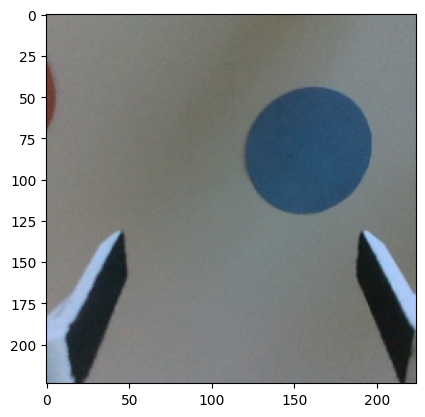

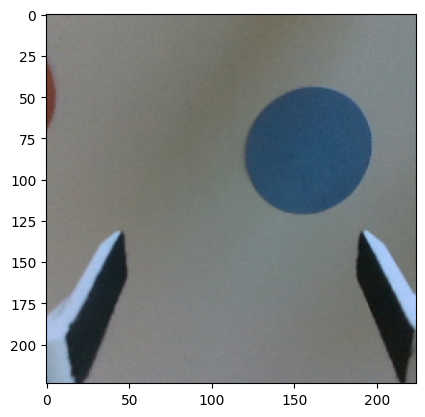

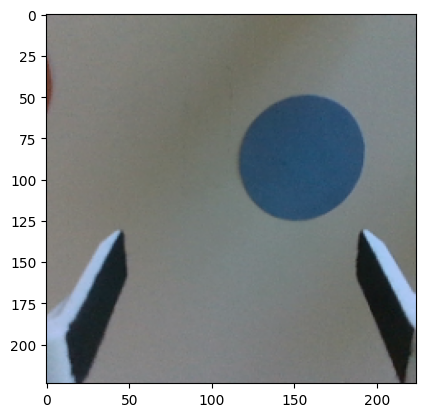

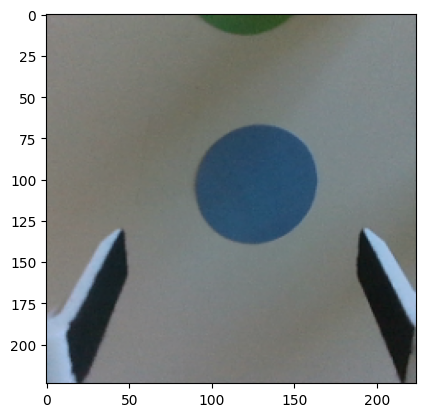

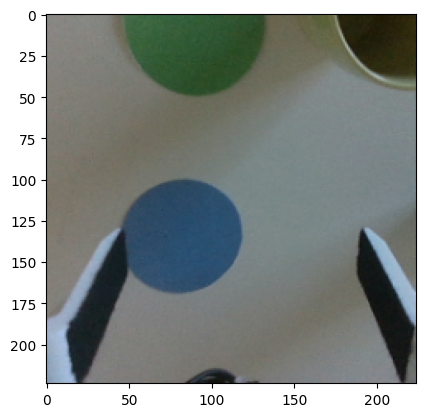

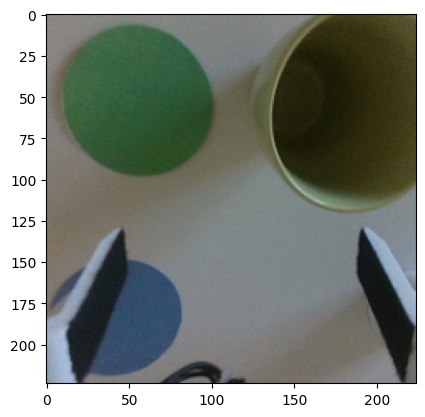

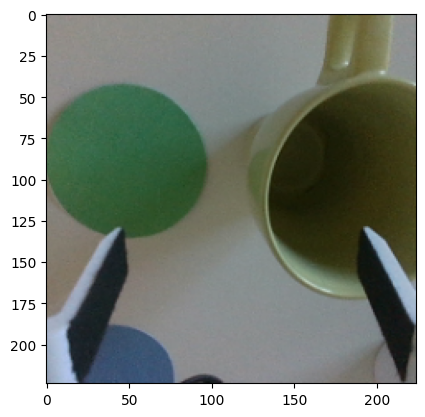

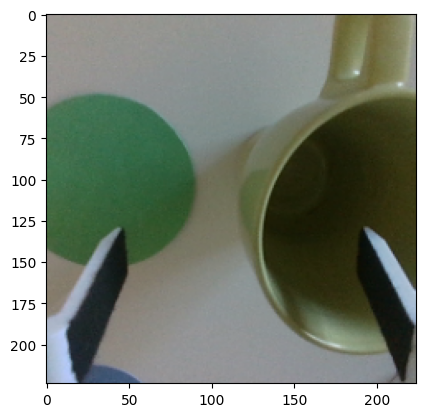

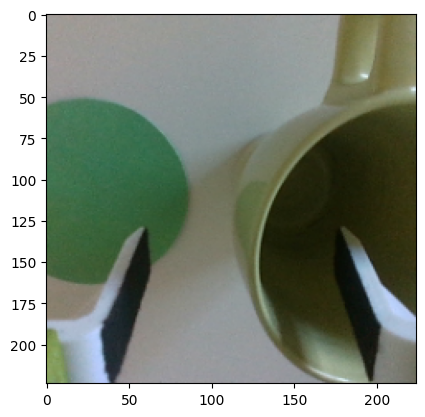

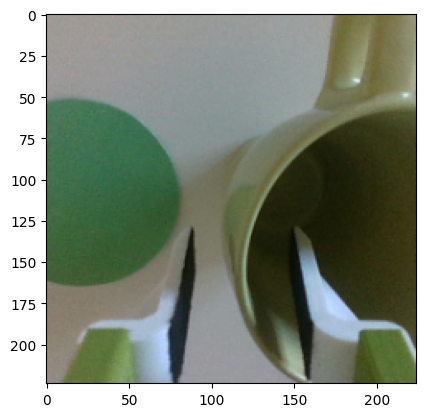

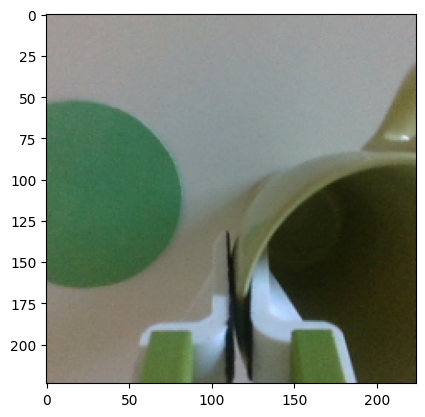

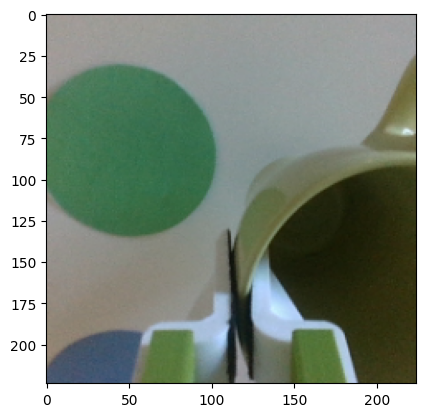

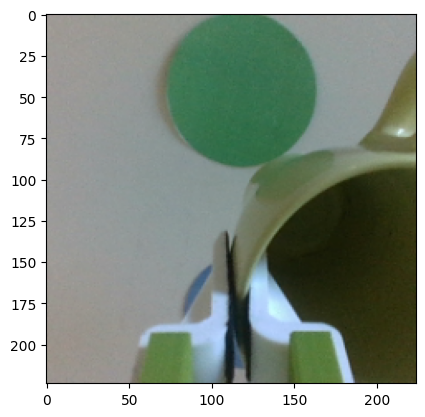

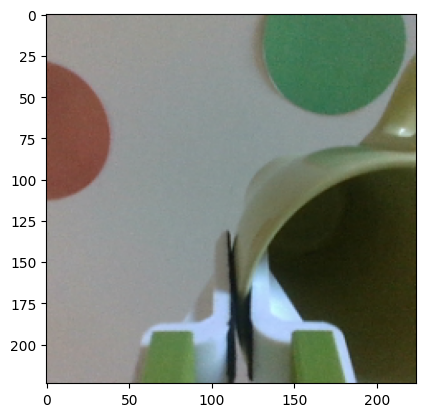

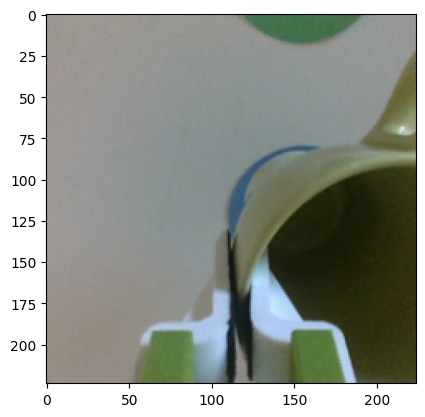

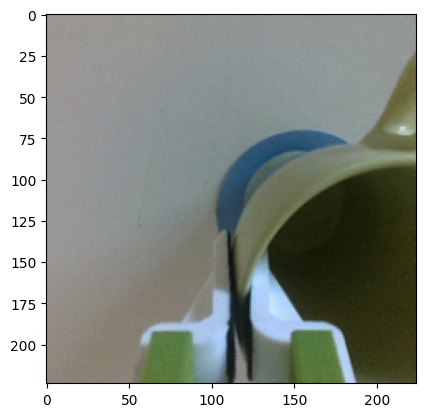

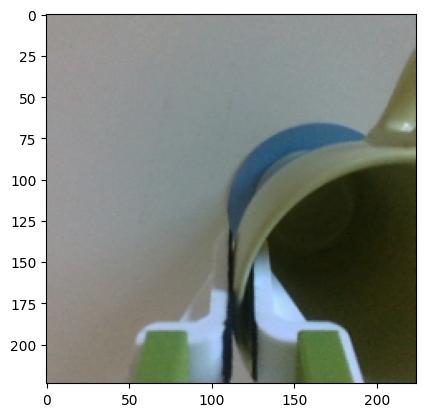

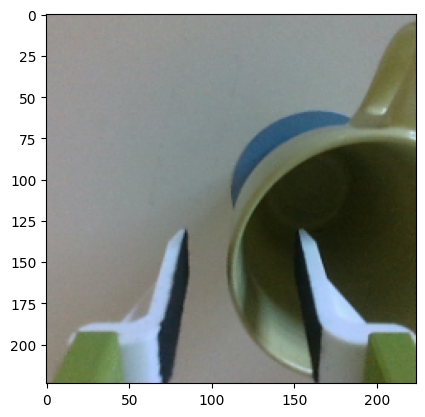

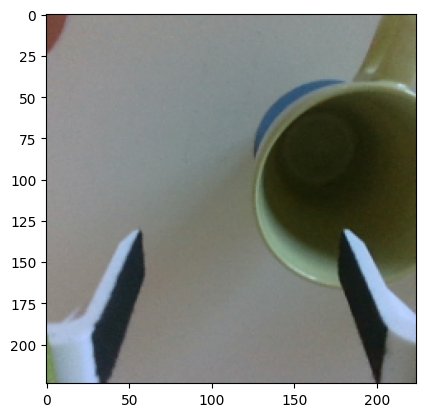

In [ ]:
import matplotlib.pyplot as plt


for i in range(0,len(data),10):
    plt.imshow(data[i][0].external_camera_rgb_image)
    plt.show()

In [5]:
ls data/recorded_trajectory/belt_finger_vla_benchmark

badminton_in_cup/      lerobot_datasets/         place_chess/
lego_rotation_blue/    pick_and_insert_tea_bag/
lego_rotation_orange/  pick_comb/


In [9]:
import zmq
import json
import numpy as np
from dataclasses import dataclass
import time
import pickle

def pose_4x4_to_9d(pose_matrix: np.ndarray) -> np.ndarray:
    pos_3d = pose_matrix[..., :3, 3]  # Shape: (..., 3)
    R_3x3 = pose_matrix[..., :3, :3]  # Shape: (..., 3, 3)
    col1 = R_3x3[..., :, 0]  # Shape: (..., 3)
    col2 = R_3x3[..., :, 1]  # Shape: (..., 3)
    state_9d = np.concatenate([pos_3d, col1, col2], axis=-1) # Shape: (..., 9)
    return state_9d

def get_action(state, socket):
    meta = []
    payloads = []

    # Add cmd first
    meta.append({"name": "cmd", "shape": 1, "dtype": "text"})
    payloads.append("inference".encode('utf-8')) 

    # Add state
    for key in  state:
        if key == "task":
            meta.append({"name": key, "shape": 1, "dtype": "text"})
            payloads.append(state[key].encode('utf-8')) 
        else:
            arr = state[key]
            meta.append({"name": key, "shape": arr.shape, "dtype": str(arr.dtype)})
            payloads.append(arr.tobytes())
    meta_bytes  = json.dumps(meta).encode('utf-8')
    socket.send_multipart([meta_bytes, *payloads])

    reply_parts = socket.recv_multipart()

    out_meta = json.loads(reply_parts[0].decode('utf-8'))
    out_data = reply_parts[1]
    result  = np.frombuffer(out_data, dtype=out_meta['dtype']).reshape(out_meta['shape'])
    return result

# test reset
def reset_policy(socket):
    meta = [{"name": "cmd", "shape": 1, "dtype": "text"}]
    payloads = ["reset".encode('utf-8')]
    meta_bytes  = json.dumps(meta).encode('utf-8')
    socket.send_multipart([meta_bytes, *payloads])
    reply_parts = socket.recv_multipart()
    print("Policy reset.")

def get_gt_state_action():
    path = "data/recorded_trajectory/belt_finger_vla_benchmark/lego_rotation_blue/recorded_traj_1.npy"
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    reset_policy(socket)
    infered_actions = []
    gt_actions = []
    for state, action in data:
        gt_actions.append(np.concatenate([action.eef_action, action.gripper_action], axis=0))
        state: RobotState
        action:RobotAction
        policy_input_state = {}
        policy_input_state["observation.images.wrist"] = state.wrist_camera_rgb_image
        policy_input_state["observation.images.external"] = state.external_camera_rgb_image
        policy_input_state["observation.state"] = np.concatenate([state.q, np.array([state.gripper_width]), pose_4x4_to_9d(state.eef_pose)], axis=0)
        policy_input_state["task"] = "shift this object much higher"

        action = get_action(policy_input_state, socket)
        infered_actions.append(action[0])
    return np.stack(infered_actions, axis=0), np.stack(gt_actions, axis=0)

ctx    = zmq.Context()
socket = ctx.socket(zmq.REQ)
socket.connect("tcp://127.0.0.1:6008")



<SocketContext(connect='tcp://127.0.0.1:6008')>

In [7]:
infered_actions, gt_actions = get_gt_state_action()

Policy reset.


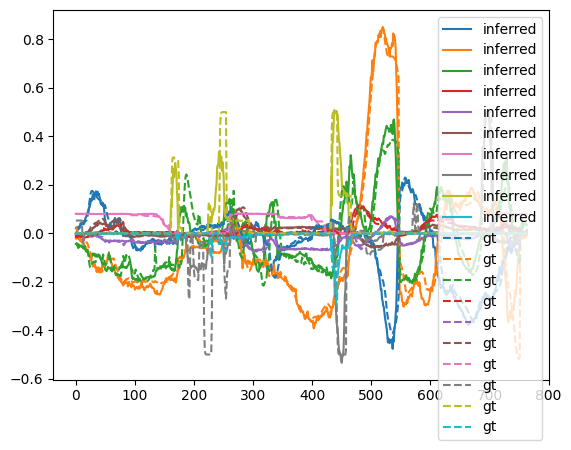

In [8]:
plt.plot(np.arange(infered_actions.shape[0]), infered_actions, label="inferred")
plt.plot(np.arange(gt_actions.shape[0]), gt_actions, '--', label="gt")
plt.legend()

/tmp/ipykernel_125753/383033820.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


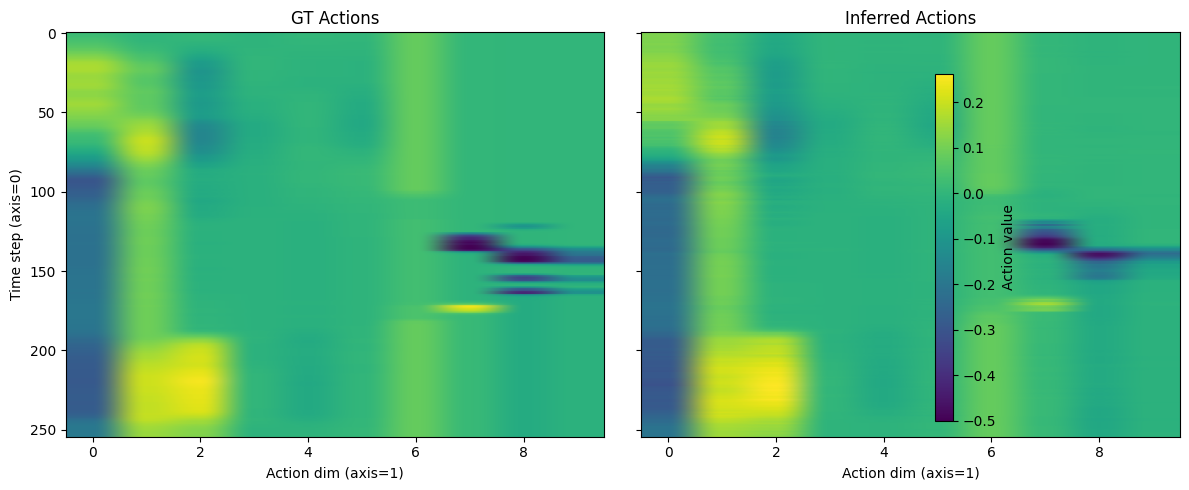

In [13]:
import matplotlib.pyplot as plt
vmin = min(infered_actions.min(), gt_actions.min())
vmax = max(infered_actions.max(), gt_actions.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

im0 = axes[0].imshow(gt_actions, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title("GT Actions")
axes[0].set_xlabel("Action dim (axis=1)")
axes[0].set_ylabel("Time step (axis=0)")

im1 = axes[1].imshow(infered_actions, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title("Inferred Actions")
axes[1].set_xlabel("Action dim (axis=1)")

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("Action value")

plt.tight_layout()
plt.show()

In [12]:
gt_actions.shape

(255, 10)